In [18]:
import sys
!{sys.executable} -m pip install mlflow azureml-mlflow kaggle mltable azureml-automl-runtime



  Installing build dependencies ... - \ | done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 76.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.9/987.9 kB 34.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 134.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 82.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 116.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 86.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 84.3 MB/s  0:00:

## 1. Conexión al Workspace

In [2]:
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

ml_client = MLClient.from_config(credential=DefaultAzureCredential())

# Verificar conexión
ws = ml_client.workspaces.get(ml_client.workspace_name)
print(f"Workspace: {ws.name}")
print(f"Region: {ws.location}")


Found the config file in: /config.json


Workspace: azure-ml-ajzv
Region: southcentralus


## 2. Crear Cluster de Compute
AutoML necesita un recurso de compute para ejecutar los experimentos. Crearemos un cluster que escale automáticamente:


In [2]:
from azure.ai.ml.entities import AmlCompute
from azure.core.exceptions import ResourceNotFoundError

cluster_name = "automl-forecast-cluster"

try:
    compute = ml_client.compute.get(cluster_name)
    print(f"Cluster existente: {cluster_name}")
except ResourceNotFoundError:
    compute = AmlCompute(
        name=cluster_name,
        size="STANDARD_DS3_V2",
        min_instances=0,    # Escala a 0 cuando no se usa
        max_instances=4,    # Maximo 4 nodos
        idle_time_before_scale_down=120  # Segundos
    )
    poller = ml_client.begin_create_or_update(compute)
    poller.wait()
    print(f"Cluster creado: {cluster_name}")


Cluster existente: automl-forecast-cluster


## 3. Explorar y Preparar los Datos

In [17]:
import pandas as pd
data_asset = ml_client.data.get("Bike-Sharing-Demand", version="1")

df = pd.read_csv(data_asset.path)

Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [19]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
display(df.head())



Filas: 10886, Columnas: 12


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [22]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


None

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


## 4. Preparar los Datos para AutoML
AutoML para forecasting requiere al mínimo dos columnas: una columna de tiempo y una columna objetivo (target). Prepararemos los datos adecuadamente:


In [26]:
import os
# Renombrar columna target para claridad
df.rename(columns={'count': 'cnt', 'datetime': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])

# Eliminar columnas de fuga (leak columns)
# casual + registered = cnt, asi que las eliminamos
df.drop(['casual', 'registered'], axis=1,
        inplace=True, errors='ignore')

# Dividir en entrenamiento y prueba
train_end = pd.Timestamp('2012-10-15')
train_df = df[df['date'] <= train_end]
test_df = df[df['date'] > train_end]

print(f"Train: {len(train_df)} filas")
print(f"Test: {len(test_df)} filas")

# Guardar como Parquet
os.makedirs('./data/train', exist_ok=True)
os.makedirs('./data/test', exist_ok=True)
train_df.to_parquet('./data/train/train.parquet')
test_df.to_csv('./data/test/test.csv', index=False)


Train: 9856 filas
Test: 1030 filas


## 5. Crear MLTable para Azure ML

In [27]:
# Crear archivo MLTable YAML
mltable_content = """
type: mltable
paths:
  - file: ./train.parquet
transformations:
  - read_parquet
"""

with open('./data/train/MLTable', 'w') as f:
    f.write(mltable_content)

print("MLTable creado exitosamente")


MLTable creado exitosamente


## 6. Cargar los Datos en Azure ML

In [28]:
from azure.ai.ml import Input
from azure.ai.ml.constants import AssetTypes

# Datos de entrenamiento (MLTable)
training_data_input = Input(
    type=AssetTypes.MLTABLE,
    path='./data/train'
)

# Datos de prueba (para evaluacion posterior)
test_data_input = Input(
    type=AssetTypes.URI_FOLDER,
    path='./data/test'
)

print("Datos configurados como Input")


Datos configurados como Input


## 7. Configuración del Trabajo

In [29]:
from azure.ai.ml import automl

# Parametros principales
target_column = "cnt"
time_column = "date"
forecast_horizon = 14  # Predecir 14 periodos
experiment_name = "bike-sharing-forecast"

# Crear el trabajo de forecasting
forecasting_job = automl.forecasting(
    experiment_name=experiment_name,
    training_data=training_data_input,
    target_column_name=target_column,
    primary_metric="NormalizedRootMeanSquaredError",
    n_cross_validations="auto",
    enable_model_explainability=True,
    compute=cluster_name,
)


## 8. Configurar Límites de Entrenamiento

In [30]:
# Limites de tiempo y recursos
forecasting_job.set_limits(
    timeout_minutes=60,
    trial_timeout_minutes=10,
    max_concurrent_trials=4,
    enable_early_termination=True,
)


## 9. Configurar Parámetros de Forecasting

In [31]:
# Configuracion especifica de series temporales
forecasting_job.set_forecast_settings(
    time_column_name=time_column,
    forecast_horizon=forecast_horizon,
    frequency="H",           # Frecuencia horaria
    target_lags="auto",       # Lags automaticos
    target_rolling_window_size="auto",
    country_or_region_for_holidays="US",
)


## 10. Enviar el trabajo

In [32]:
# Enviar el trabajo de AutoML
returned_job = ml_client.jobs.create_or_update(
    forecasting_job
)

print(f"Trabajo creado: {returned_job.name}")
print(f"Estado: {returned_job.status}")
print(f"URL del Studio: {returned_job.studio_url}")


Uploading train (0.2 MBs): 100%|██████████| 201700/201700 [00:00<00:00, 27853393.37it/s]




Trabajo creado: neat_night_62lnrdx1wq
Estado: NotStarted
URL del Studio: https://ml.azure.com/runs/neat_night_62lnrdx1wq?wsid=/subscriptions/2ccc5a14-5d6f-4688-baa4-4d902c103b85/resourcegroups/gr-machinelearning/workspaces/azure-ml-ajzv&tid=c65a3ea6-0f7c-400b-8934-5a6dc1705645


## 11. Analizar los Resultados y Métricas

In [3]:
import mlflow
from mlflow.tracking.client import MlflowClient
from mlflow.artifacts import download_artifacts

# Configurar URI de tracking
MLFLOW_TRACKING_URI = ml_client.workspaces.get(
    name=ml_client.workspace_name
).mlflow_tracking_uri

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow_client = MlflowClient()
print(f"Tracking URI: {MLFLOW_TRACKING_URI}")


Tracking URI: azureml://southcentralus.api.azureml.ms/mlflow/v2.0/subscriptions/2ccc5a14-5d6f-4688-baa4-4d902c103b85/resourceGroups/gr-machinelearning/providers/Microsoft.MachineLearningServices/workspaces/azure-ml-ajzv


In [4]:
# Obtener el run padre
job_name = "neat_night_62lnrdx1wq"
parent_run = mlflow_client.get_run(job_name)

# ID del mejor modelo hijo
best_child_run_id = parent_run.data.tags[
    "automl_best_child_run_id"
]
print(f"Mejor modelo: {best_child_run_id}")

# Obtener detalles del mejor run
best_run = mlflow_client.get_run(best_child_run_id)


Mejor modelo: neat_night_62lnrdx1wq_30


In [7]:
# Features de Ingeniería Automática AutoML genera automáticamente features temporales. Puedes inspeccionarlas

import pandas as pd

# Mostrar todas las metricas del mejor modelo
metrics_df = pd.DataFrame(
    best_run.data.metrics, index=[0]
).T
metrics_df.columns = ['Valor']
print(metrics_df)


                                            Valor
normalized_mean_absolute_error           0.030233
r2_score                                 0.952583
spearman_correlation                     0.944388
normalized_root_mean_squared_error       0.040772
mean_absolute_percentage_error          21.491754
explained_variance                       0.957872
root_mean_squared_error                 39.793466
median_absolute_error                   20.859830
mean_absolute_error                     29.507158
normalized_root_mean_squared_log_error   0.042290
root_mean_squared_log_error              0.261875
normalized_median_absolute_error         0.021373


In [9]:
import os

# Descargar artefactos
local_dir = "./artifact_downloads/"
os.makedirs(local_dir, exist_ok=True)

local_path = download_artifacts(
    run_id=best_run.info.run_id,
    artifact_path="outputs",
    dst_path=local_dir
)

print(f"Artefactos en: {local_path}")
print(os.listdir(local_path))


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artefactos en: /mnt/batch/tasks/shared/LS_root/mounts/clusters/a017963631-automated/code/Users/A01796363/artifact_downloads/outputs
['conda_env_v_1_0_0.yml', 'engineered_feature_names.json', 'env_dependencies.json', 'featurization_summary.json', 'generated_code', 'internal_cross_validated_models.pkl', 'mlflow-model', 'model.pkl', 'pipeline_graph.json', 'run_id.txt', 'scoring_file_pbi_v_1_0_0.py', 'scoring_file_v_1_0_0.py', 'scoring_file_v_2_0_0.py']


In [10]:
import json

# Ver features generados automaticamente
with open(os.path.join(local_path,
    'engineered_feature_names.json'), 'r') as f:
    features = json.load(f)

print("Features generados:")
for feat in features:
    print(f"  - {feat}")

# Resumen de featurizacion
with open(os.path.join(local_path,
    'featurization_summary.json'), 'r') as f:
    feat_summary = json.load(f)

fs_df = pd.DataFrame.from_records(feat_summary)
print(fs_df[['RawFeatureName', 'TypeDetected',
             'Dropped', 'EngineeredFeatureCount',
             'Transformations']])


Features generados:
  - _automl_target_col_WASNULL
  - atemp
  - atemp_WASNULL
  - holiday
  - holiday_WASNULL
  - horizon_origin
  - humidity
  - humidity_WASNULL
  - season
  - season_WASNULL
  - temp
  - temp_WASNULL
  - weather
  - weather_WASNULL
  - windspeed
  - windspeed_WASNULL
  - workingday
  - workingday_WASNULL
  - _automl_target_col_occurrence_lag1H
  - _automl_target_col_occurrence_lag2H
  - _automl_target_col_min_window3H
  - _automl_target_col_max_window3H
  - _automl_target_col_mean_window3H
  - _automl_year
  - _automl_half
  - _automl_quarter
  - _automl_month
  - _automl_day
  - _automl_hour
  - _automl_am_pm
  - _automl_hour12
  - _automl_wday
  - _automl_qday
  - _automl_week
       RawFeatureName TypeDetected Dropped  EngineeredFeatureCount  \
0  _automl_target_col      Numeric      No                       6   
1               atemp      Numeric      No                       2   
2             holiday      Numeric      No                       2   
3           

## 12. Registrar modelo

In [11]:
from azure.ai.ml.entities import Model
import datetime

model_name = "bike-share-forecast"

model = Model(
    path=f"azureml://jobs/{best_run.info.run_id}"
         f"/outputs/artifacts/outputs/model.pkl",
    name=model_name,
    description="Modelo de forecasting de demanda "
               "de bicicletas - AutoML",
    type="custom_model"
)

registered_model = ml_client.models.create_or_update(
    model
)
print(f"Modelo registrado: {registered_model.name}")
print(f"Version: {registered_model.version}")


Modelo registrado: bike-share-forecast
Version: 1


In [12]:
# Crear Entorno de Inferencia
from azure.ai.ml.entities import (
    Environment, BatchEndpoint, BatchDeployment,
    BatchRetrySettings
)
from azure.ai.ml.constants import (
    BatchDeploymentOutputAction
)

# Crear entorno desde conda del modelo
env = Environment(
    name="automl-forecast-env",
    description="Entorno para inferencia AutoML",
    image="mcr.microsoft.com/azureml/"
         "openmpi4.1.0-ubuntu22.04:latest",
    conda_file="artifact_downloads/outputs/"
              "conda_env_v_1_0_0.yml"
)


In [13]:
# Crear Batch Endpoint
# Nombre unico para el endpoint
endpoint_name = ("bike-forecast-" +
    datetime.datetime.now().strftime("%m%d%H%M"))

endpoint = BatchEndpoint(
    name=endpoint_name,
    description="Endpoint de forecasting"
)

ml_client.begin_create_or_update(
    endpoint
).wait()
print(f"Endpoint creado: {endpoint_name}")


Endpoint creado: bike-forecast-03230308


## 13. Realizar Predicciones

In [22]:
!pip install scipy==1.10.1 azureml-automl-runtime azureml-train-automl-client --force-reinstall --no-deps

  Using cached scipy-1.10.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
  Using cached azureml_automl_runtime-1.62.0-py3-none-any.whl.metadata (3.2 kB)
Using cached scipy-1.10.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.4 MB)
Using cached azureml_automl_runtime-1.62.0-py3-none-any.whl (1.8 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Uninstalling scipy-1.10.1:
      Successfully uninstalled scipy-1.10.1
  Attempting uninstall: azureml-train-automl-clientm 0/3 [scipy]
    Found existing installation: azureml-train-automl-client 1.61.0y]
    Uninstalling azureml-train-automl-client-1.61.0:2m0/3 [scipy]
      Successfully uninstalled azureml-train-automl-client-1.61.0━ 1/3 [azureml-train-automl-client]
  Attempting uninstall: azureml-automl-runtime━━━━━━━━━━━━━━━━━━━━ 1/3 [azureml-train-automl-client]
    Found existing installation: azureml-automl-runtime 1.61.0 1/3 [azureml-train-automl-client]
 

In [6]:
import mlflow
import pandas as pd

# Cargar el mejor modelo directamente
model_uri = f"runs:/{best_child_run_id}/outputs/mlflow-model"
model = mlflow.pyfunc.load_model(model_uri)

# Cargar datos de prueba
test_df = pd.read_csv('./data/test/test.csv', parse_dates=['date'])

# Hacer predicciones
predictions = model.predict(test_df)
print(predictions)

2026/03/23 03:22:43 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - arch (current: 8.0.0, required: arch==5.6.0)
 - azure-core (current: 1.37.0, required: azure-core==1.36.0)
 - azure-identity (current: 1.25.1, required: azure-identity==1.17.0)
 - azure-monitor-opentelemetry-exporter (current: 1.0.0b46, required: azure-monitor-opentelemetry-exporter==1.0.0b40)
 - azure-storage-blob (current: 12.27.1, required: azure-storage-blob==12.19.0)
 - azure-storage-queue (current: uninstalled, required: azure-storage-queue==12.14.1)
 - azureml-automl-core (current: 1.62.0, required: azureml-automl-core==1.61.0.post1)
 - azureml-automl-runtime (current: 1.62.0, required: azureml-automl-runtime==1.61.0)
 - azureml-dataprep (current: 5.1.6, required: azureml-dataprep==5.4.2)
 - azureml-dataprep-native (current: 41.0.0, required: azureml-dataprep-native==42.1.0)
 - azureml-dataprep-rslex (current: 2.22.5

[ 29.   6.   4. ... 168. 129.  88.]


In [17]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

test_df = pd.read_csv('./data/test/test.csv', parse_dates=['date'])
test_forecast = test_df.copy()
y_actual = test_forecast['cnt'].values
test_forecast['cnt'] = np.nan

predictions_nan = model.predict(test_forecast)
print("LISTO")
print(f"Longitud: {len(predictions_nan)}")
print(f"Primeros 10: {predictions_nan[:10]}")

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/azureml/training/tabular/featurization/timeseries/rolling_window.py:893: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for grain, df in X.data.groupby(X.time_series_id_column_names, group_keys=False):
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/azureml/training/tabular/models/forecasting_pipeline_wrapper.py:333: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for tsid, df_one in Xy_pred.groupby(self.grain_column_names):
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/azureml/training/tabular/timeseries/_frequency_fixer.py:577: FutureWarning: In a

LISTO
Longitud: 1030
Primeros 10: [ 21.22944333  14.19367492  10.2712481   13.91718513  28.71514024
 153.60451946 466.92896528 655.11440088 221.83063843 191.76698042]


MAE:  34.74
RMSE: 51.82
R2:   0.9267


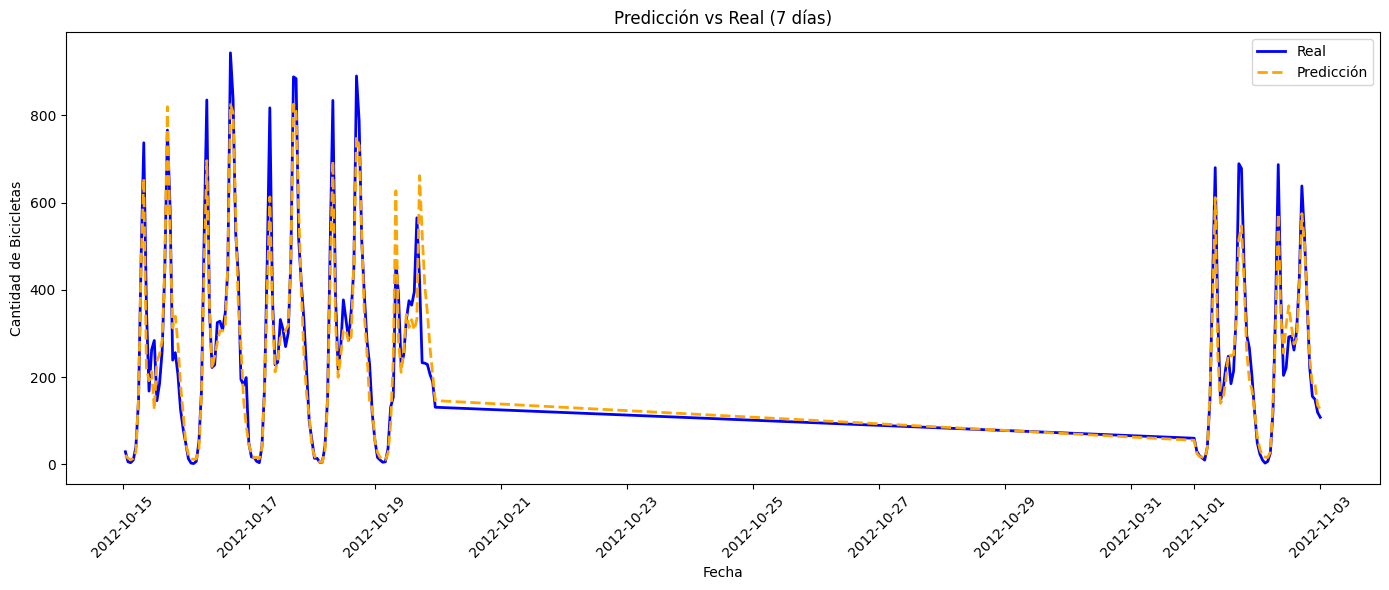

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

mae = mean_absolute_error(y_actual, predictions_nan)
rmse = np.sqrt(mean_squared_error(y_actual, predictions_nan))
r2 = r2_score(y_actual, predictions_nan)
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

results = test_df.copy()
results['predicted'] = predictions_nan
zoom = results.head(168)

plt.figure(figsize=(14, 6))
plt.plot(zoom['date'], zoom['cnt'],
         label='Real', color='blue', linewidth=2)
plt.plot(zoom['date'], zoom['predicted'],
         label='Predicción', color='orange',
         linestyle='--', linewidth=2)
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Bicicletas')
plt.title('Predicción vs Real (7 días)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()